# Day 2 - In class assignment ( Twitter dataset sentiment classifier )

**Tasks:**

1. Build a 3-class sentiment classifier: positive / neutral / negative, and report F1-score per class.
2. Run spaCy NER on 20 random tweets and tabulate the entities found.
3. Train LDA with 5 topics and name each topic based on the top 10 words.

The preprocessing is given extra attention because the dataset is Twitter data and contains usernames, links, hashtags, short forms, and punctuation noise.


## 0. Install / import libraries

In Colab, spaCy is usually installed, but the small English model may need to be downloaded. Run this cell first.


In [1]:
# If this fails in Colab, run it once and then restart runtime if needed.
!python -m spacy download en_core_web_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import LatentDirichletAllocation

import spacy

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Load the dataset

Upload `Tweets.csv` into the Colab session before running the next cell.


In [3]:
# Option 1: If Tweets.csv is uploaded directly to Colab
DATA_PATH = "Tweets.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [5]:
# We mainly need the tweet text and sentiment label
print(df.columns.tolist())
print("Sentiment distribution:")
print(df['airline_sentiment'].value_counts())


['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']
Sentiment distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


## 2. Preprocess / clean tweets

Twitter data is noisy. The cleaning function below handles:

- URLs
- Twitter usernames like `@VirginAmerica`
- hashtags
- contractions like `can't` → `cannot`
- punctuation and numbers
- extra spaces

 Sentiment words like `not`, `no`, `never` are not removed, because they are very important for sentiment classification.


In [7]:
# Text cleaning / preprocessing
def clean_tweet(text):
    text = str(text).lower()

    # Expand a few common contractions before removing punctuation
    contractions = {
        "can't": "cannot", "won't": "will not", "n't": " not",
        "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
        "'ve": " have", "'m": " am"
    }

    for short, full in contractions.items():
        text = text.replace(short, full)

    # Remove URLs and usernames
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)

    # Remove hashtag symbol only
    text = text.replace("#", "")

    # Keep only alphabets and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df['clean_text'] = df['text'].apply(clean_tweet)

df[['text', 'clean_text', 'airline_sentiment']].head(10)


,text,clean_text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,what said,neutral
1,@VirginAmerica plus you've added commercials t...,plus you have added commercials to the experie...,positive
2,@VirginAmerica I didn't today... Must mean I n...,i did not today must mean i need to take anoth...,neutral
3,@VirginAmerica it's really aggressive to blast...,it is really aggressive to blast obnoxious ent...,negative
4,@VirginAmerica and it's a really big bad thing...,and it is a really big bad thing about it,negative
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay a flight for seats that di...,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...,positive
7,@VirginAmerica Really missed a prime opportuni...,really missed a prime opportunity for men with...,neutral
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",well i did not but now i do d,positive
9,"@VirginAmerica it was amazing, and arrived an ...",it was amazing and arrived an hour early you a...,positive


In [8]:
# Check for empty cleaned tweets
empty_count = (df['clean_text'].str.len() == 0).sum()
print("Empty cleaned tweets:", empty_count)

df = df[df['clean_text'].str.len() > 0].copy()


Empty cleaned tweets: 0


# Q1. Build a 3-class sentiment classifier

I am using:

- **TF-IDF vectorizer** with unigram + bigram features
- **Linear SVM classifier** because it works well for text classification
- **Stratified train-test split** so the positive/neutral/negative ratio is preserved
- **Class weight = balanced** to help with class imbalance


In [9]:
X = df['clean_text']
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])


Training size: 11712
Testing size: 2928


In [10]:
sentiment_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    ('classifier', LinearSVC(
        class_weight='balanced',
        C=0.7,
        random_state=RANDOM_STATE
    ))
])

sentiment_model.fit(X_train, y_train)
y_pred = sentiment_model.predict(X_test)


In [11]:
# Classification report gives precision, recall, and F1-score per class
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T
report_df


,precision,recall,f1-score,support
negative,0.862520,0.899183,0.880470,1835.000000
neutral,0.633117,0.629032,0.631068,620.000000
positive,0.776942,0.655391,0.711009,473.000000
accuracy,0.802596,0.802596,0.802596,0.802596
macro avg,0.757526,0.727869,0.740849,2928.000000
weighted avg,0.800119,0.802596,0.800284,2928.000000


In [12]:
# F1 score per class
f1_per_class = report_df.loc[['negative', 'neutral', 'positive'], ['f1-score', 'support']]
f1_per_class


,f1-score,support
negative,0.880470,1835.0
neutral,0.631068,620.0
positive,0.711009,473.0


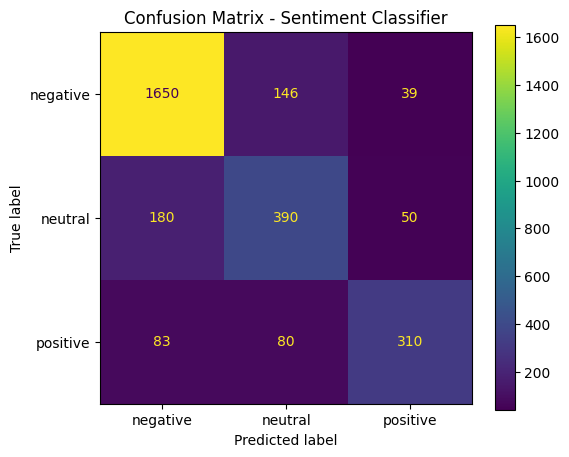

In [13]:
# Confusion matrix for better understanding
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, values_format='d')
plt.title('Confusion Matrix - Sentiment Classifier')
plt.show()


###  Conclusion

The model reports F1-score separately for negative, neutral, and positive classes. Negative usually performs best because the dataset contains many more negative tweets. Neutral and positive are harder because they have fewer samples and their language overlaps more.


# Q2. Run spaCy NER on 20 random tweets

Here I use spaCy's `en_core_web_sm` model. I sample 20 random original tweets, run NER, and store the entities in a table.


In [14]:
nlp = spacy.load('en_core_web_sm')

sample_tweets = df[['tweet_id', 'text', 'airline_sentiment']].sample(20, random_state=RANDOM_STATE).reset_index(drop=True)

ner_rows = []

for idx, row in sample_tweets.iterrows():
    doc = nlp(row['text'])
    if len(doc.ents) == 0:
        ner_rows.append({
            'tweet_no': idx + 1,
            'tweet_id': row['tweet_id'],
            'tweet': row['text'],
            'entity_text': 'No entity found',
            'entity_label': '-',
            'entity_explanation': '-'
        })
    else:
        for ent in doc.ents:
            ner_rows.append({
                'tweet_no': idx + 1,
                'tweet_id': row['tweet_id'],
                'tweet': row['text'],
                'entity_text': ent.text,
                'entity_label': ent.label_,
                'entity_explanation': spacy.explain(ent.label_)
            })

ner_df = pd.DataFrame(ner_rows)
ner_df


,tweet_no,tweet_id,tweet,entity_text,entity_label,entity_explanation
0,1,569731104070115329,@SouthwestAir you're my early frontrunner for ...,oscars2016,PERSON,"People, including fictional"
1,2,569263373092823040,@USAirways how is it that my flt to EWR was Ca...,EWR,ORG,"Companies, agencies, institutions, etc."
2,2,569263373092823040,@USAirways how is it that my flt to EWR was Ca...,NYC,LOC,"Non-GPE locations, mountain ranges, bodies of ..."
3,2,569263373092823040,@USAirways how is it that my flt to EWR was Ca...,USAirways,ORG,"Companies, agencies, institutions, etc."
4,3,568818669024907264,@JetBlue what is going on with your BDL to DCA...,BDL,ORG,"Companies, agencies, institutions, etc."
5,3,568818669024907264,@JetBlue what is going on with your BDL to DCA...,DCA,ORG,"Companies, agencies, institutions, etc."
6,3,568818669024907264,@JetBlue what is going on with your BDL to DCA...,yesterday,DATE,Absolute or relative dates or periods
7,3,568818669024907264,@JetBlue what is going on with your BDL to DCA...,today,DATE,Absolute or relative dates or periods
8,4,567775864679456768,@JetBlue do they have to depart from Washingto...,Washington,GPE,"Countries, cities, states"
9,4,567775864679456768,@JetBlue do they have to depart from Washingto...,D.C.,GPE,"Countries, cities, states"


In [15]:
# Compact view: one row per tweet with all entities joined together
compact_ner = ner_df.groupby(['tweet_no', 'tweet_id', 'tweet'], as_index=False).agg({
    'entity_text': lambda x: ', '.join(x),
    'entity_label': lambda x: ', '.join(x)
})
compact_ner


,tweet_no,tweet_id,tweet,entity_text,entity_label
0,1,569731104070115329,@SouthwestAir you're my early frontrunner for ...,oscars2016,PERSON
1,2,569263373092823040,@USAirways how is it that my flt to EWR was Ca...,"EWR, NYC, USAirways","ORG, LOC, ORG"
2,3,568818669024907264,@JetBlue what is going on with your BDL to DCA...,"BDL, DCA, yesterday, today","ORG, ORG, DATE, DATE"
3,4,567775864679456768,@JetBlue do they have to depart from Washingto...,"Washington, D.C.","GPE, GPE"
4,5,568526521910079488,@JetBlue I can probably find some of them. Are...,No entity found,-
5,6,570008443626647552,@united still waiting to hear back. My wallet ...,one,CARDINAL
6,7,568622671287566336,@united Yes my flight was rebooked. I'm just l...,No entity found,-
7,8,569076569983086592,@JetBlue Thank you ! What about Paris ? Could ...,Paris,GPE
8,9,568884344221081600,"@united not 100% sure, however my ticket inclu...",100%,PERCENT
9,10,570119853312311296,@usairways great crew for flight 504 PHX to YV...,"504, PHX, YVR, tonight","CARDINAL, ORG, ORG, TIME"


###  Conclusion

spaCy can detect common entities such as organizations, dates, locations, times, and money-related terms. In tweets, NER may miss some entities because tweets are short, informal, and contain usernames or abbreviations.


# Q3. Train LDA with 5 topics

LDA is an unsupervised topic modeling technique. For this task:

- I use cleaned tweets.
- I remove common English stopwords.
- I also remove airline names and very common Twitter words, because otherwise topics become dominated by airline names.
- I train LDA with **5 topics**.
- For each topic, I show the **top 10 words** and give a human-readable topic name.


In [16]:
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    'flight', 'flights', 'airline', 'airlines',
    'virginamerica', 'united', 'southwestair', 'delta', 'usairways', 'americanair', 'jetblue',
    'amp', 'http', 'https', 'co', 'rt', 'aa', 'dm',
    'just', 'thanks', 'thank', 'please', 'plane', 'airport',
    'get', 'got', 'like', 'im', 'u', 'us', 'would'
})

count_vectorizer = CountVectorizer(
    stop_words=list(custom_stopwords),
    max_df=0.80,
    min_df=20,
    max_features=2000,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)

dtm = count_vectorizer.fit_transform(df['clean_text'])
print("Document-term matrix shape:", dtm.shape)


Document-term matrix shape: (14640, 889)


In [17]:
lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=RANDOM_STATE,
    learning_method='online',
    max_iter=5,
    batch_size=1024,
    evaluate_every=-1
)

lda_model.fit(dtm)


LatentDirichletAllocation(batch_size=1024, learning_method='online', max_iter=5,
                          n_components=5, random_state=42)

In [18]:
feature_names = count_vectorizer.get_feature_names_out()

def get_top_words(model, feature_names, n_top_words=10):
    topic_rows = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topic_rows.append({
            'topic_number': topic_idx,
            'top_10_words': ', '.join(top_words)
        })
    return pd.DataFrame(topic_rows)

topic_words_df = get_top_words(lda_model, feature_names, 10)
topic_words_df


,topic_number,top_10_words
0,0,"service, customer, great, guys, problems, wors..."
1,1,"cancelled, flightled, hold, help, hours, waiti..."
2,2,"bag, time, need, told, bags, yes, baggage, fly..."
3,3,"weather, luggage, help, seat, change, said, bo..."
4,4,"hours, staff, phone, way, delay, hold, number,..."


In [19]:
# Topic names are manually assigned after looking at the top 10 words.
# We can slightly edit these names if your LDA output changes after rerunning.

def suggest_topic_name(words):
    words = words.lower()
    if any(w in words for w in ['bag', 'baggage', 'luggage']):
        return 'Baggage / luggage issues'
    elif any(w in words for w in ['cancelled', 'delayed', 'late', 'weather', 'tomorrow']):
        return 'Delays and cancellations'
    elif any(w in words for w in ['service', 'customer', 'phone', 'response', 'hold']):
        return 'Customer service and support'
    elif any(w in words for w in ['gate', 'hours', 'minutes', 'help']):
        return 'Waiting time and gate support'
    elif any(w in words for w in ['work', 'problems', 'fly', 'need']):
        return 'General travel problems'
    else:
        return 'General airline feedback'


topic_words_df['suggested_topic_name'] = topic_words_df['top_10_words'].apply(suggest_topic_name)
topic_words_df


,topic_number,top_10_words,suggested_topic_name
0,0,"service, customer, great, guys, problems, wors...",Customer service and support
1,1,"cancelled, flightled, hold, help, hours, waiti...",Delays and cancellations
2,2,"bag, time, need, told, bags, yes, baggage, fly...",Baggage / luggage issues
3,3,"weather, luggage, help, seat, change, said, bo...",Baggage / luggage issues
4,4,"hours, staff, phone, way, delay, hold, number,...",Customer service and support


In [20]:
# assign the most likely topic to each tweet ( Optional )

topic_distribution = lda_model.transform(dtm)
df['lda_topic'] = topic_distribution.argmax(axis=1)

topic_name_map = dict(zip(topic_words_df['topic_number'], topic_words_df['suggested_topic_name']))
df['lda_topic_name'] = df['lda_topic'].map(topic_name_map)

df[['text', 'airline_sentiment', 'lda_topic', 'lda_topic_name']].head(10)


,text,airline_sentiment,lda_topic,lda_topic_name
0,@VirginAmerica What @dhepburn said.,neutral,3,Baggage / luggage issues
1,@VirginAmerica plus you've added commercials t...,positive,0,Customer service and support
2,@VirginAmerica I didn't today... Must mean I n...,neutral,1,Delays and cancellations
3,@VirginAmerica it's really aggressive to blast...,negative,3,Baggage / luggage issues
4,@VirginAmerica and it's a really big bad thing...,negative,0,Customer service and support
5,@VirginAmerica seriously would pay $30 a fligh...,negative,4,Customer service and support
6,"@VirginAmerica yes, nearly every time I fly VX...",positive,2,Baggage / luggage issues
7,@VirginAmerica Really missed a prime opportuni...,neutral,2,Baggage / luggage issues
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",positive,3,Baggage / luggage issues
9,"@VirginAmerica it was amazing, and arrived an ...",positive,1,Delays and cancellations


### Conclusion

LDA produced 5 groups of commonly occurring words. Since LDA gives only topic numbers and top words, I manually named each topic based on the top 10 words. This is normal in topic modeling because the algorithm does not understand human-friendly topic names by itself.
